# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import pandas as pd
from sqlalchemy import create_engine 
import matplotlib.pyplot as plt
import seaborn as sns
import os   
from dotenv import load_dotenv 

In [2]:
load_dotenv(dotenv_path='env.env')
secret_user = os.getenv('USER')
secret_pwd = os.getenv('PWD')
secret_host = os.getenv('HOST')
secret_port = os.getenv('PORT')
secret_db = os.getenv('DB')

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    secret_user,
    secret_pwd,
    secret_host,
    secret_port,
    secret_db,
) 
engine = create_engine(connection_string) 

In [3]:
query = '''
SELECT
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk,
  created_ts_msk,
  currency_code,
  revenue,
  tickets_count,
  EXTRACT(DAY FROM created_dt_msk - (LAG (created_dt_msk,1,NULL) OVER (PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
  event_id,
  event_name_code AS event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
FROM afisha.purchases p
LEFT JOIN afisha.events USING(event_id) 
LEFT JOIN afisha.city USING(city_id) 
LEFT JOIN afisha.regions USING(region_id) 
WHERE (((p.device_type_canonical = 'mobile') OR (p.device_type_canonical = 'desktop')) AND NOT (event_type_main = 'фильм'))
ORDER BY user_id
''' 
df = pd.read_sql_query(query, con=engine) 

**Итог:** Выгружены данные о пользователях и заказах

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[us]
 4   created_ts_msk         290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [5]:
df.head()

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


**Итог:** Необходимо скорректировать типы данных, пропусков нет нигде, кроме 'days_since_prev'.  Некоторые данные можно сократить по размеру. Общий вес данных 75.2 MB

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [6]:
tickets_tenge_df =pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv').set_index('data')
print('\nОбщая информация о данных')
print(tickets_tenge_df.info())
print('\nПримеры данных')
print(tickets_tenge_df.head())
print('\nинформация о числовых данных в dataframe')
print(tickets_tenge_df.describe())


Общая информация о данных
<class 'pandas.DataFrame'>
Index: 357 entries, 2024-01-10 to 2024-12-31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nominal  357 non-null    int64  
 1   curs     357 non-null    float64
 2   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 15.7 KB
None

Примеры данных
            nominal     curs  cdx
data                             
2024-01-10      100  19.9391  kzt
2024-01-11      100  19.7255  kzt
2024-01-12      100  19.5839  kzt
2024-01-13      100  19.4501  kzt
2024-01-14      100  19.4501  kzt

информация о числовых данных в dataframe
       nominal        curs
count    357.0  357.000000
mean     100.0   19.755818
std        0.0    0.833798
min      100.0   17.848600
25%      100.0   19.120200
50%      100.0   19.876000
75%      100.0   20.443300
max      100.0   21.937100


In [7]:
def convert_kzt_to_rub(row):
#     print(str(row['created_dt_msk'].date()))
    if row['currency_code'] == 'kzt':
        str_date = str(row['created_dt_msk'].date())
        curs, nominal = tickets_tenge_df.loc[str_date, ['curs','nominal']]
        return round(row['revenue'] * curs / nominal, 2)
    else:
        return row['revenue']
df = df[df['revenue'] >= 0]
df['revenue_rub'] = df[['created_dt_msk','currency_code','revenue']].apply(convert_kzt_to_rub, axis=1)
df.info()

# print(df['revenue_rub'])

<class 'pandas.DataFrame'>
Index: 290230 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290230 non-null  str           
 1   device_type_canonical  290230 non-null  str           
 2   order_id               290230 non-null  int64         
 3   created_dt_msk         290230 non-null  datetime64[us]
 4   created_ts_msk         290230 non-null  datetime64[us]
 5   currency_code          290230 non-null  str           
 6   revenue                290230 non-null  float64       
 7   tickets_count          290230 non-null  int64         
 8   days_since_prev        268329 non-null  float64       
 9   event_id               290230 non-null  int64         
 10  event_name             290230 non-null  str           
 11  event_type_main        290230 non-null  str           
 12  service_name           290230 non-null  str           
 13  

**Итог:** Добавлено поле 'revenue_rub' в котором цены только в рублях. Операция по преобразованию заняло много времени, так как данные переберались построчно  
'revenue_rub' имеет отрицательные значения, произведена фильтрация таких значений, ибо невозможно понять при каких условиях выручка оказалось отрицательной

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

**Комментарий:** Данные из базы данных загружены корректно

In [8]:
# Сокращаем всевозможные типы
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['days_since_prev'] = df['days_since_prev'].astype('Int16')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')
df.info()

<class 'pandas.DataFrame'>
Index: 290230 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290230 non-null  str           
 1   device_type_canonical  290230 non-null  str           
 2   order_id               290230 non-null  int32         
 3   created_dt_msk         290230 non-null  datetime64[us]
 4   created_ts_msk         290230 non-null  datetime64[us]
 5   currency_code          290230 non-null  str           
 6   revenue                290230 non-null  float64       
 7   tickets_count          290230 non-null  int8          
 8   days_since_prev        268329 non-null  Int16         
 9   event_id               290230 non-null  int32         
 10  event_name             290230 non-null  str           
 11  event_type_main        290230 non-null  str           
 12  service_name           290230 non-null  str           
 13  

**Комментарий:** Данные были максимально сокращены, что позволило сократить более 5 MB

In [9]:
print(f"Уникальные типы устройств: {df['device_type_canonical'].unique()}")
print(f"Уникальные валюты оплаты: {df['currency_code'].unique()}")
print(f"Уникальные типы события: {df['event_type_main'].unique()}")
print(f"Уникальные сайты оплаты: {df['service_name'].unique()}")

Уникальные типы устройств: <ArrowStringArray>
['mobile', 'desktop']
Length: 2, dtype: str
Уникальные валюты оплаты: <ArrowStringArray>
['rub', 'kzt']
Length: 2, dtype: str
Уникальные типы события: <ArrowStringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str
Уникальные сайты оплаты: <ArrowStringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
              

**Комментарий:** номинальные данные не имеют названия полей которые бы условно обозначали NaN. Нормализация не требуется. Сайты оплаты названы так же как и названы их юридические наименования

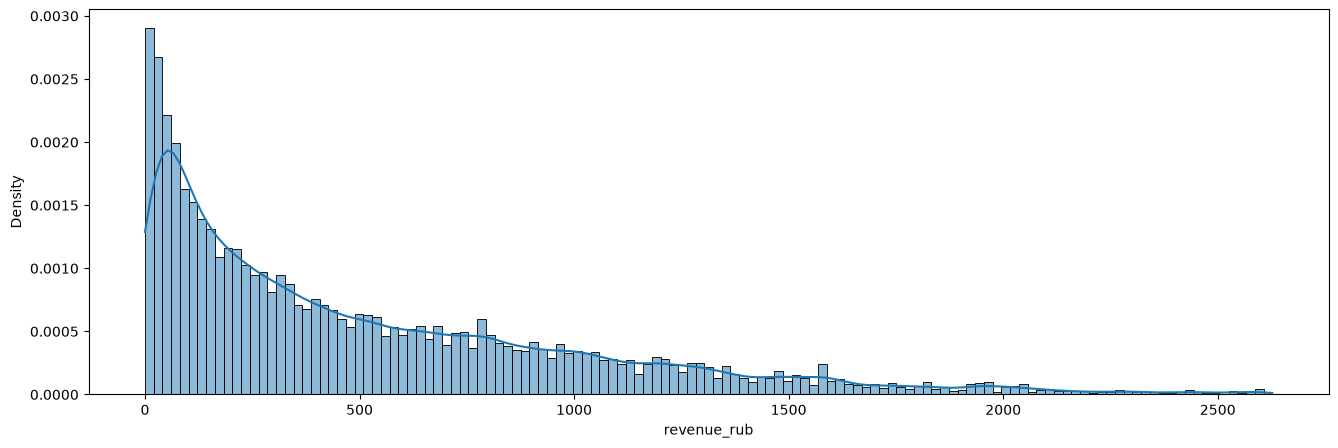

In [10]:
p99 = df["revenue_rub"].quantile(0.99)
plt.figure(figsize=(16, 5))
df = df[df["revenue_rub"] < p99]
sns.histplot(df['revenue_rub'], kde=True, stat="density")
plt.show()

**Итог:** Были сокращены и изменены некоторые типы данных, дупликатов и пропусков не имеется кроме запланированныз пропусков в 'days_since_prev'. Гистограмма цен имеет левоассиметричное распределение и имеется некоторое количество положительных выбросов

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [11]:
user_profile_df = df.sort_values('created_ts_msk').groupby('user_id').agg({
    'created_ts_msk' : ['max', 'min'],
    'device_type_canonical' : 'first',
    'region_name' : 'first',
    'service_name' : 'first',
    'event_type_main' : 'first',
    'order_id' : 'count',
    'revenue_rub' : 'mean',
    'tickets_count' : 'mean',
    'days_since_prev' : 'mean',
})
user_profile_df.columns = user_profile_df.columns.to_flat_index().map('_'.join)
user_profile_df = user_profile_df.reset_index()
user_profile_df['is_two'] = user_profile_df['order_id_count'] > 1
user_profile_df['is_five'] = user_profile_df['order_id_count'] > 4

In [12]:
user_profile_df.head()

,user_id,created_ts_msk_max,created_ts_msk_min,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,2024-10-06 13:56:02,2024-07-23 18:36:24,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-10-23 15:12:00,2024-07-13 19:40:48,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False
4,000a55a418c128c,2024-10-15 10:29:04,2024-09-29 19:39:12,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


**Комментарий:** создана таблица профиля пользователя

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [13]:
users = user_profile_df['user_id'].count()
mean_revenue = (user_profile_df['order_id_count'] * user_profile_df['revenue_rub_mean']).sum() / (user_profile_df['order_id_count'].sum())
is_two_part = user_profile_df['is_two'].sum() / user_profile_df['is_two'].count()
is_five_part = user_profile_df['is_five'].sum() / user_profile_df['is_five'].count()

In [14]:
print(f'количество пользователей: {users}')
print(f'средняя выручку с одного заказа: {round(mean_revenue, 2)}')
print(f'доля пользователей, совершивших 2 и более заказа: {round(is_two_part * 100, 2)}%')
print(f'доля пользователей, совершивших 5 и более заказов: {round(is_five_part * 100, 2)}%')

количество пользователей: 21832
средняя выручку с одного заказа: 517.38
доля пользователей, совершивших 2 и более заказа: 61.71%
доля пользователей, совершивших 5 и более заказов: 28.99%


In [15]:
describes = [user_profile_df['order_id_count'].describe(),user_profile_df['tickets_count_mean'].describe(),user_profile_df['days_since_prev_mean'].describe()]
statistic_data = pd.concat(describes, axis = 1)
statistic_data.columns = ['общее число заказов','среднее числу билетов в заказе','среднее количеству дней между покупками']
statistic_data


,общее число заказов,среднее числу билетов в заказе,среднее количеству дней между покупками
count,21832.000000,21832.000000,13508.0
mean,13.156055,2.743852,15.859534
std,121.526670,0.913391,22.321504
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.0
50%,2.000000,2.750000,8.0
75%,5.000000,3.080000,20.428571
max,10162.000000,11.000000,148.0


**Комментарий:** существует аномалия по общему числу заказов. Рекомендуется отфильтровать данные по 95 проценталю по общему числу заказов

In [16]:
p95 = user_profile_df['order_id_count'].quantile(0.95)
user_profile_df = user_profile_df[user_profile_df['order_id_count'] < p95]

In [17]:
users = user_profile_df['user_id'].count()
mean_revenue = (user_profile_df['order_id_count'] * user_profile_df['revenue_rub_mean']).sum() / (user_profile_df['order_id_count'].sum())
is_two_part = user_profile_df['is_two'].sum() / user_profile_df['is_two'].count()
is_five_part = user_profile_df['is_five'].sum() / user_profile_df['is_five'].count()
print(f'количество пользователей: {users}')
print(f'средняя выручку с одного заказа: {round(mean_revenue, 2)}')
print(f'доля пользователей, совершивших 2 и более заказа: {round(is_two_part * 100, 2)}%')
print(f'доля пользователей, совершивших 5 и более заказов: {round(is_five_part * 100, 2)}%')

количество пользователей: 20711
средняя выручку с одного заказа: 543.74
доля пользователей, совершивших 2 и более заказа: 59.63%
доля пользователей, совершивших 5 и более заказов: 25.15%


In [18]:
describes = [user_profile_df['order_id_count'].describe(),user_profile_df['tickets_count_mean'].describe(),user_profile_df['days_since_prev_mean'].describe()]
statistic_data = pd.concat(describes, axis = 1)
statistic_data.columns = ['общее число заказов','среднее числу билетов в заказе','среднее количеству дней между покупками']
statistic_data

,общее число заказов,среднее числу билетов в заказе,среднее количеству дней между покупками
count,20711.000000,20711.000000,12387.0
mean,4.009077,2.744473,17.094549
std,5.011307,0.935406,22.90871
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.0
50%,2.000000,2.750000,9.5
75%,5.000000,3.166667,22.2
max,30.000000,11.000000,148.0


**Итог:** Были отсортированы данные по общему числу заказов и при этом остальные данные изменились незначительно. Общая выборка данных упала незначительно

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [19]:
def feature_table(feature_column):
    df = pd.DataFrame(columns=['user_feature_type','user_count', 'user_count_part'])
    
    df['user_count'] = user_profile_df.groupby([feature_column])['user_id'].count() # .sort_values(ascending = False)
    df['user_count_part'] = df['user_count'] / len(user_profile_df) * 100
    df.loc[:, 'user_feature_type'] = feature_column 
    df['is_two_count'] = user_profile_df.groupby([feature_column])['is_two'].sum() #.sort_values(ascending = False)
    df['is_two_part'] = df['is_two_count'] / len(user_profile_df) * 100
    df['single_enter_part'] = 100 - df['is_two_part']
    return df
    
full_feature_segments_table = pd.concat([
    feature_table('event_type_main_first'),
    feature_table('device_type_canonical_first'),
    feature_table('region_name_first'),
    feature_table('service_name_first')
]).sort_values(by='user_count_part', ascending = False).reset_index()
full_feature_segments_table = full_feature_segments_table.rename(columns={"index": "segment"})
full_feature_segments_table.head(10)

,segment,user_feature_type,user_count,user_count_part,is_two_count,is_two_part,single_enter_part
0,mobile,device_type_canonical_first,17180,82.951089,10161,49.060886,50.939114
1,концерты,event_type_main_first,9167,44.261504,5518,26.642847,73.357153
2,Каменевский регион,region_name_first,6775,32.712085,4110,19.844527,80.155473
3,другое,event_type_main_first,5152,24.875670,2968,14.330549,85.669451
4,Билеты без проблем,service_name_first,4948,23.890686,2898,13.992564,86.007436
5,театр,event_type_main_first,4065,19.627251,2513,12.133649,87.866351
6,Североярская область,region_name_first,3596,17.362754,2233,10.781710,89.218290
7,desktop,device_type_canonical_first,3531,17.048911,2190,10.574091,89.425909
8,Мой билет,service_name_first,2840,13.712520,1681,8.116460,91.883540
9,Лови билет!,service_name_first,2703,13.051036,1605,7.749505,92.250495


**Комментарий:** Создана удобная таблица для сегментов и признаков, где данные будет удобно группировать и фильтровать

**Итог:** По каждому признаку присутствуют ярко выраженные точки входа:  
   - для первого мероприятия — концерт
   - для первого устройства — мобильное
   - для первого региона — каменевский
   - для первого билетного оператора — Билеты без проблем

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


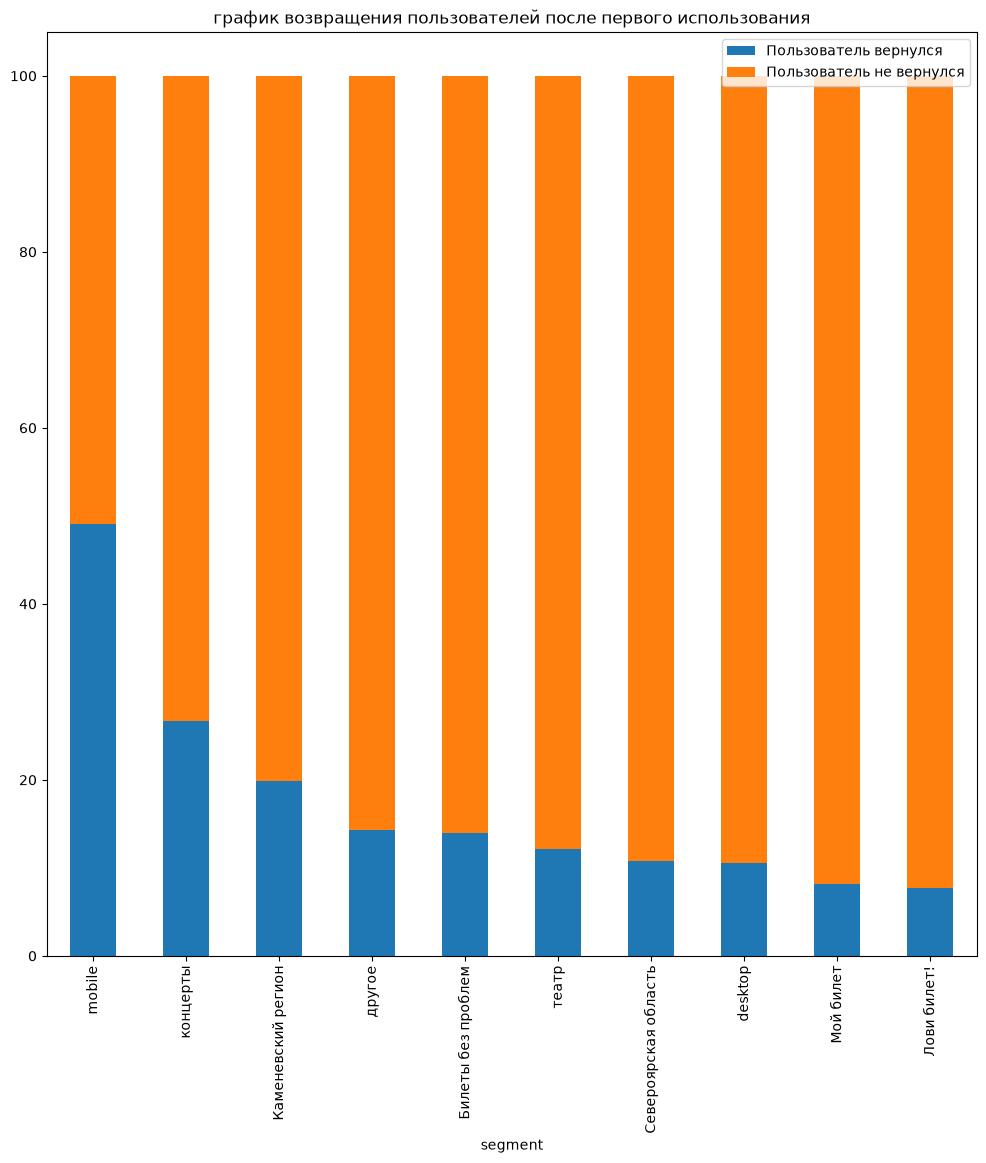

In [20]:
full_feature_segments_table[['segment','is_two_part','single_enter_part']].set_index('segment').sort_values(by='is_two_part', ascending = False).head(10).plot(
    kind='bar',
    stacked=True,
    figsize = (12,12),
    title = 'график возвращения пользователей после первого использования'
)
plt.legend(['Пользователь вернулся', 'Пользователь не вернулся'])
plt.show()

In [21]:
print(f'среднее количество пользователей, которые возвращаются по сегментам: {full_feature_segments_table["is_two_count"].mean()}')
print(f'средняя доля пользователей, которые возвращаются по сегментам: {full_feature_segments_table["is_two_part"].mean()} %')
full_feature_segments_table[full_feature_segments_table["is_two_count"].mean() < full_feature_segments_table["is_two_count"]]

среднее количество пользователей, которые возвращаются по сегментам: 398.4193548387097
средняя доля пользователей, которые возвращаются по сегментам: 1.9237089220158832 %


,segment,user_feature_type,user_count,user_count_part,is_two_count,is_two_part,single_enter_part
0,mobile,device_type_canonical_first,17180,82.951089,10161,49.060886,50.939114
1,концерты,event_type_main_first,9167,44.261504,5518,26.642847,73.357153
2,Каменевский регион,region_name_first,6775,32.712085,4110,19.844527,80.155473
3,другое,event_type_main_first,5152,24.875670,2968,14.330549,85.669451
4,Билеты без проблем,service_name_first,4948,23.890686,2898,13.992564,86.007436
5,театр,event_type_main_first,4065,19.627251,2513,12.133649,87.866351
6,Североярская область,region_name_first,3596,17.362754,2233,10.781710,89.218290
7,desktop,device_type_canonical_first,3531,17.048911,2190,10.574091,89.425909
8,Мой билет,service_name_first,2840,13.712520,1681,8.116460,91.883540
9,Лови билет!,service_name_first,2703,13.051036,1605,7.749505,92.250495


**Итог:** Самые выраженные сегменты по возвращению пользователей это: покупка билетов через мобильный телефон. Выше представлена таблица всех успешных точек входа

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

- **(ЧАСТИЧНО ВЕРНО) Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу, однако ситуация относительно концерта и спортивного мероприятия противоположная, кто заказал билет на концерт с большей вероятностью вернется. 48.92% против 2.03 %
- **(ВЕРНО) Гипотеза 2.** Первые 3 региона действительно показывают такую тенденцию. Чем больше людей посещяет мероприятие в региона, тем чаще они возвращаются

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


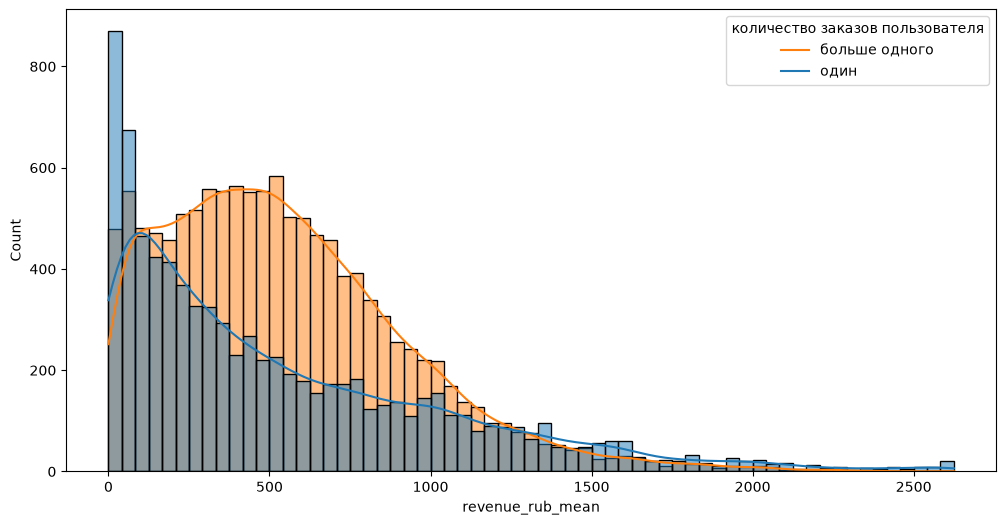

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=user_profile_df[['is_two','revenue_rub_mean']],
    x='revenue_rub_mean',
    hue='is_two',
    kde=True
)
plt.legend(title='количество заказов пользователя', labels = ['больше одного','один'])
plt.show()

In [23]:
user_profile_df[~user_profile_df['is_two']][['is_two','revenue_rub_mean']].describe()

,revenue_rub_mean
count,8360.000000
mean,544.697612
std,517.164576
min,0.000000
25%,133.005000
50%,378.545000
75%,828.730000
max,2624.810000


**Комментарий:** выше представлено описание распределения средней выручки у единичных пользователей

In [24]:
user_profile_df[user_profile_df['is_two']][['is_two','revenue_rub_mean']].describe()

,revenue_rub_mean
count,12351.000000
mean,547.688405
std,377.567876
min,0.000000
25%,261.322417
50%,494.704000
75%,762.423750
max,2624.810000


**Комментарий:** выше представлено описание распределения средней выручки у возвращающихся пользователей

**Итог:** Из группы, где пользователи заказывали билеты более одного раза, первый и третий квартиль средней выручки составляют 241.48 рублей и 663.89 рублей.  
В это же время первый и третий квартиль средней выручки пользователей, которые заказывали билеты 1 раз составляют  от 126.59 рублей до 770.30 рублей.  
Между группами заметны различия. Пользователи, которые возвращаются по несколько раз, склонны в среднем тратить больше за раз. Однако в области 1100 рублей графики пересекаются и случайный пользователь с большей вероятностью потратит более 1150 рублей, чем возвращающийся

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [25]:
user_profile_df['is_two_four'] = user_profile_df['is_two'] & (~user_profile_df['is_five']) # новый столбец для пользователей с 2-4 заказами

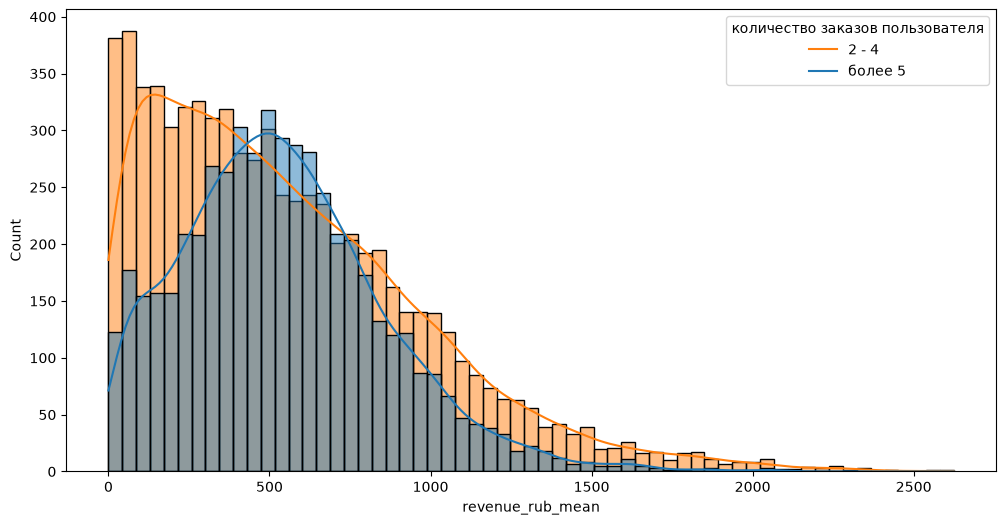

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=user_profile_df[user_profile_df['is_two']][['is_two_four','revenue_rub_mean']],
    x='revenue_rub_mean',
    hue='is_two_four',
    kde=True
)
plt.legend(title='количество заказов пользователя', labels = ['2 - 4','более 5'])
plt.show()

**Итог:** Различия действительно присутствуют и с учетом предыдущей визуализации можно сказать, что чем больше раз пользователь делал заказ, тем сильнее график средней выручки приближается к нормальному распределению с центром в значении 500 рублей.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

**Комментарий:** так как в задании не уточнено, я приму эти области чисел, включая крайние значения

In [27]:
df_mean_tickets_analys = pd.DataFrame(columns=['users', 'users_is_two_part'])
full_users = user_profile_df['user_id'].count()

new_user_area = user_profile_df[
    (user_profile_df['tickets_count_mean'] >= 1) &
    (user_profile_df['tickets_count_mean'] <= 2)
]
df_mean_tickets_analys.loc['from 1 to 2 tickets','users'] = new_user_area['user_id'].count()
df_mean_tickets_analys.loc['from 1 to 2 tickets','users_is_two_part'] = new_user_area['is_two'].count() / full_users

new_user_area = user_profile_df[
    (user_profile_df['tickets_count_mean'] >= 2) &
    (user_profile_df['tickets_count_mean'] <= 3)
]
df_mean_tickets_analys.loc['from 2 to 3 tickets','users'] = new_user_area['user_id'].count()
df_mean_tickets_analys.loc['from 2 to 3 tickets','users_is_two_part'] = new_user_area['is_two'].count() / full_users

new_user_area = user_profile_df[
    (user_profile_df['tickets_count_mean'] >= 3) &
    (user_profile_df['tickets_count_mean'] <= 5)
]
df_mean_tickets_analys.loc['from 3 to 5 tickets','users'] = new_user_area['user_id'].count()
df_mean_tickets_analys.loc['from 3 to 5 tickets','users_is_two_part'] = new_user_area['is_two'].count() / full_users

new_user_area = user_profile_df[
    (user_profile_df['tickets_count_mean'] >= 5)
]
df_mean_tickets_analys.loc['5 and more tickets','users'] = new_user_area['user_id'].count()
df_mean_tickets_analys.loc['5 and more tickets','users_is_two_part'] = new_user_area['is_two'].count() / full_users

# user_profile_df['tickets_count_mean_1_2'] = user_profile_df['tickets_count_mean'].apply(take_segment, axes = 1)

df_mean_tickets_analys['users_is_two'] = df_mean_tickets_analys['users'] * df_mean_tickets_analys['users_is_two_part']
df_mean_tickets_analys['users_is_not_two'] = df_mean_tickets_analys['users'] - df_mean_tickets_analys['users_is_two']
df_mean_tickets_analys

,users,users_is_two_part,users_is_two,users_is_not_two
from 1 to 2 tickets,6149,0.296895,1825.609628,4323.390372
from 2 to 3 tickets,12875,0.62165,8003.748008,4871.251992
from 3 to 5 tickets,9383,0.453044,4250.914442,5132.085558
5 and more tickets,661,0.031915,21.096084,639.903916


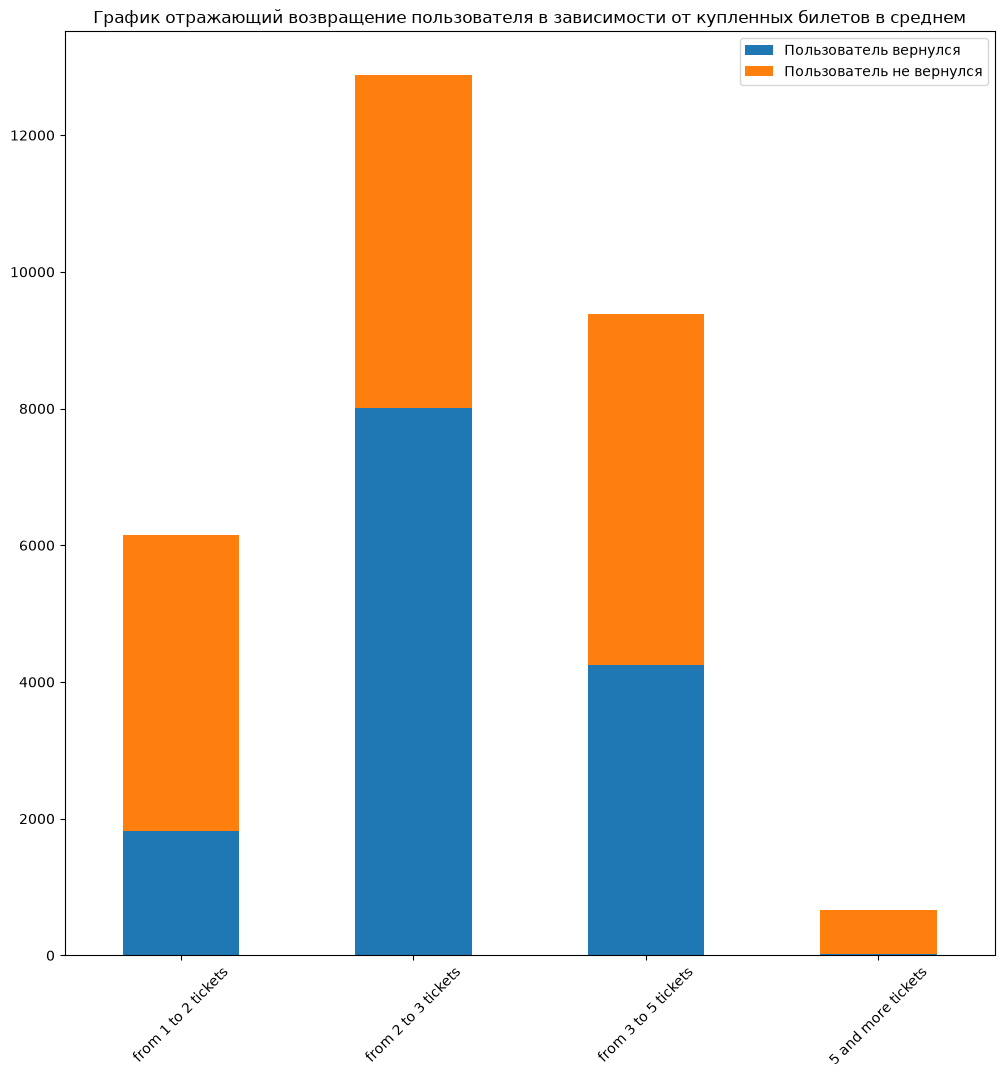

In [28]:
df_mean_tickets_analys[['users_is_two','users_is_not_two']].plot(
    kind='bar',
    stacked=True,
    figsize = (12,12),
    title = 'График отражающий возвращение пользователя в зависимости от купленных билетов в среднем',
    rot = 45
)
plt.legend(['Пользователь вернулся', 'Пользователь не вернулся'])
plt.show()

**Итог:** пользователи концентритуются в районе 2-3 билетов. Можно в общем заметить, что средняя покупка в 2-3 билета предрасполагает к возвращению пользователя в 64% процентов случаев, в то время как покупка более 5 билетов почти никогда не приводит к возвращению пользователя (возвращаются только в 3% случаев). Однако сложно назвать это аномалией, скорее естественно что не каждый может себе позволить постоянные покупки 5+ билетов

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [29]:
user_profile_df['day_name'] = user_profile_df['created_ts_msk_min'].dt.day_name()
user_profile_df['lifetime'] = pd.Timestamp.now() - user_profile_df['created_ts_msk_min'] 
buffer_df = user_profile_df[user_profile_df['is_two']]
# user_profile_df['avg_interval'] = (buffer_df['days_since_prev_mean'] * buffer_df['order_id_count']).sum() / buffer_df['order_id_count'].sum()
user_profile_df.head()

,user_id,created_ts_msk_max,created_ts_msk_min,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,is_two_four,day_name,lifetime
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False,False,Tuesday,764 days 12:13:26.072287
1,0005ca5e93f2cf4,2024-10-06 13:56:02,2024-07-23 18:36:24,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False,True,Tuesday,792 days 09:45:05.072287
2,000898990054619,2024-10-23 15:12:00,2024-07-13 19:40:48,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False,True,Saturday,802 days 08:40:41.072287
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False,False,Thursday,769 days 11:32:41.072287
4,000a55a418c128c,2024-10-15 10:29:04,2024-09-29 19:39:12,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False,True,Sunday,724 days 08:42:17.072287


**Комментарий:** Добавлены новые поля для изучения

In [30]:
df_for_dayname_plot = pd.DataFrame()
df_for_dayname_plot['user_id_count'] = user_profile_df.groupby('day_name')['user_id'].count()
df_for_dayname_plot['user_is_two_count'] = user_profile_df.groupby('day_name')['is_two'].sum()
df_for_dayname_plot['user_is_two_part'] = df_for_dayname_plot['user_is_two_count'] / df_for_dayname_plot['user_id_count']
df_for_dayname_plot['user_is_not_two_count'] = df_for_dayname_plot['user_id_count'] - df_for_dayname_plot['user_is_two_count']
df_for_dayname_plot = df_for_dayname_plot.sort_values('user_id_count', ascending = False)
df_for_dayname_plot

,user_id_count,user_is_two_count,user_is_two_part,user_is_not_two_count
day_name,,,,
Friday,3158,1847,0.584864,1311
Saturday,3118,1881,0.603271,1237
Thursday,3023,1761,0.582534,1262
Tuesday,3009,1803,0.599202,1206
Wednesday,2958,1803,0.609533,1155
Monday,2809,1729,0.615522,1080
Sunday,2636,1527,0.579287,1109


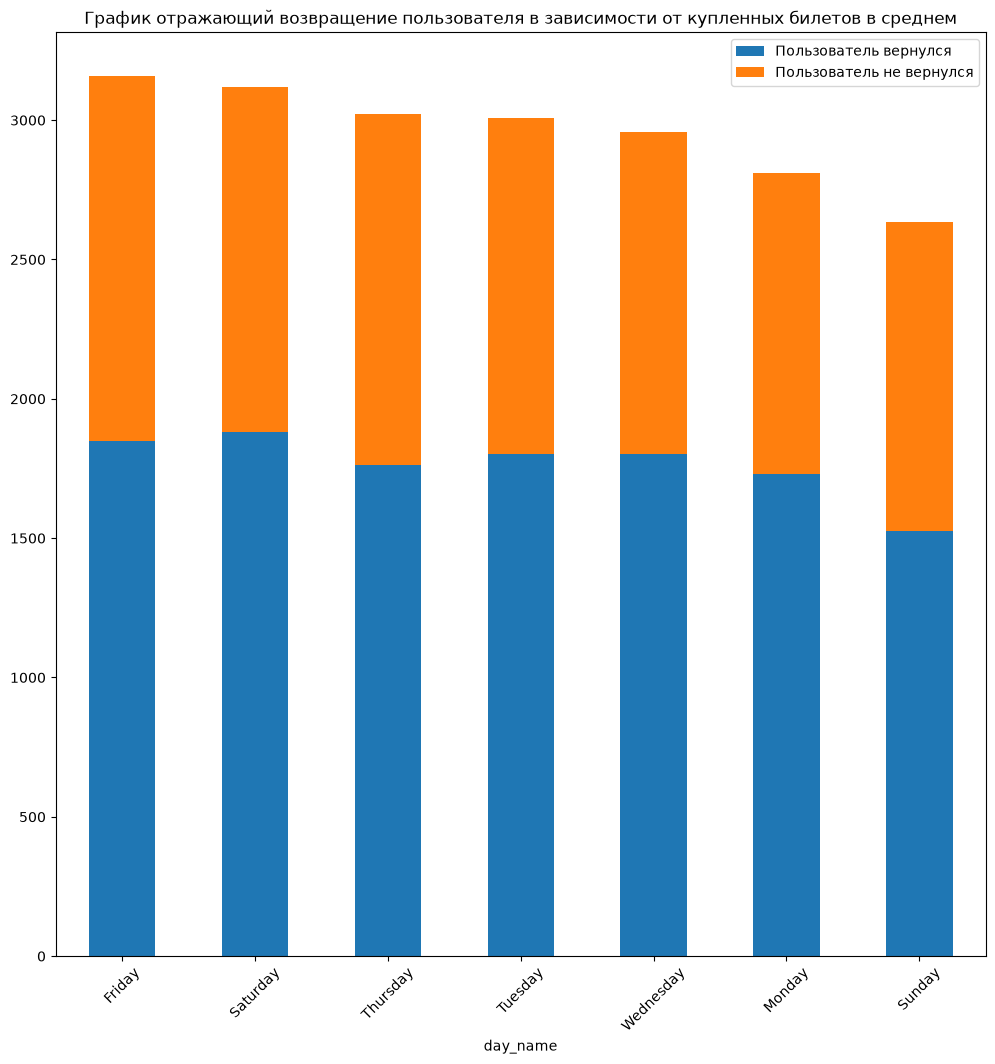

In [31]:
df_for_dayname_plot[['user_is_two_count','user_is_not_two_count']].plot(
    kind='bar',
    stacked=True,
    figsize = (12,12),
    title = 'График отражающий возвращение пользователя в зависимости от купленных билетов в среднем',
    rot = 45
    
)
plt.legend(['Пользователь вернулся', 'Пользователь не вернулся'])
plt.show()

**Итог:** день недели, в которую совершена первая покупка, не влияет на вероятность возврата клиента, в каждый день недели он равен примерно 60%

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [32]:
buffer_df = user_profile_df[user_profile_df['is_two_four']]
mean_days_since_prev_is_two_four = (buffer_df['days_since_prev_mean'] * buffer_df['order_id_count']).sum() / buffer_df['order_id_count'].sum()
print(f'среднее время между заказами для людей совершившие 2–4 заказа: {round(mean_days_since_prev_is_two_four,2)} дней')

среднее время между заказами для людей совершившие 2–4 заказа: 20.4 дней


In [33]:
buffer_df = user_profile_df[user_profile_df['is_five']]
mean_days_since_prev_is_five = (buffer_df['days_since_prev_mean'] * buffer_df['order_id_count']).sum() / buffer_df['order_id_count'].sum()
print(f'среднее время между заказами для людей совершившие 5 и более заказов: {round(mean_days_since_prev_is_five,2)} дней')

среднее время между заказами для людей совершившие 5 и более заказов: 9.32 дней


**Итог:** Согласно данным, при частом совершении предыдущих заказов, следующий заказ становится более вероятным

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

**Комментарий:** В своей работе вместо имени total_orders я использовал order_id_count

In [34]:
import phik
user_profile_df['lifetime_s'] = user_profile_df['lifetime'].dt.total_seconds()
# user_profile_df['created_ts_msk_min_s'] = user_profile_df['created_ts_msk_min'].dt.total_seconds()
full_phi_k = user_profile_df[[
    'order_id_count',
    'region_name_first',
    'device_type_canonical_first',
    'service_name_first',
    'revenue_rub_mean',
    'tickets_count_mean',
    'days_since_prev_mean', 
    'lifetime_s',
]].phik_matrix(
    interval_cols = [
        'order_id_count',
        'revenue_rub_mean',
        'tickets_count_mean',
        'days_since_prev_mean',
        'lifetime_s']
)
full_phi_k['order_id_count']

order_id_count                 1.000000
region_name_first              0.034910
device_type_canonical_first    0.051627
service_name_first             0.038322
revenue_rub_mean               0.264239
tickets_count_mean             0.295261
days_since_prev_mean           0.488814
lifetime_s                     0.424365
Name: order_id_count, dtype: float64

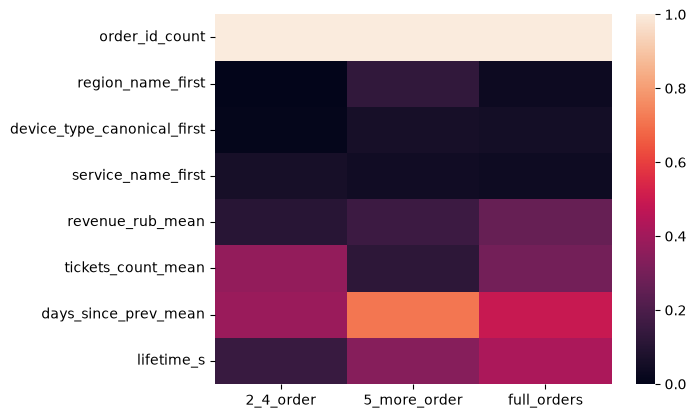

In [35]:
def make_phi_k_order_id_count(df):
    return df[[
        'order_id_count',
        'region_name_first',
        'device_type_canonical_first',
        'service_name_first',
        'revenue_rub_mean',
        'tickets_count_mean',
        'days_since_prev_mean', 
        'lifetime_s',
    ]].phik_matrix(
        interval_cols = [
            'order_id_count',
            'revenue_rub_mean',
            'tickets_count_mean',
            'days_since_prev_mean',
            'lifetime_s']
    )['order_id_count']

# phi_k_1_order = make_phi_k_order_id_count(user_profile_df[user_profile_df['order_id_count'] == 1])
phi_k_2_4_orders = make_phi_k_order_id_count(user_profile_df[(user_profile_df['order_id_count'] >=2) & (user_profile_df['order_id_count'] <=4)])
phi_k_5_more_orders = make_phi_k_order_id_count(user_profile_df[(user_profile_df['order_id_count'] >=5)])

phi_k_df = pd.DataFrame()
# phi_k_df['1_order'] = phi_k_1_order # при одном единственном значении алгоритм удаляет столбец, в любом случае его изучение будет не информативно
phi_k_df['2_4_order'] = phi_k_2_4_orders
phi_k_df['5_more_order'] = phi_k_5_more_orders
phi_k_df['full_orders'] = full_phi_k['order_id_count']

sns.heatmap(phi_k_df)
plt.show()

**Итог:** Признак 'среднее время с предыдущего заказа' имеет самую большую положительную корреляцию и связан с количеством заказов. Корреляция составила более 0.6

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Информация о данных:** Данные представляют собой таблицу заказов сервиса Яндекс Афиши. Были отфильтрованы аномальные данные с отрицательной выручкой с заказа. Так же были отфильтрованы выбросы по выручке по 99 проценталю. Выручка была приведена к одной валюте. Размерность некоторых данных была сокращена

**Основные результаты анализа:**  
- после фильтрации данных была изучена информация об 21317 пользователях, более 75% пользователей заказывали билеты до 5 раз. Далее цифры аномально вырастают вплоть до 9679. так же были изучены все признаки, с которыми пользователь сталкивается впервые.
- район, устройство, дата, билетный оператор, тип мероприятия, выручка заказа: все это связанно с первым заказом пользователей
- При малом количестве покупок в Яндекс Афише средняя цена заказа низкая, однако с каждым новым заказом средняя цена растет
- интервалы между пропусками больше всего влияют на количество заказов. Коэфициент корреляции phi_k составил около 0.6
- количество дней с предыдущей покупки

**Дополнение:** 
    В воскресные дни производится меньше всего заказов, возможно стоит в этот день как-то привлекать пользователей

**Рекомендации:** При заказе билета предоставлять пользователю скидку на следующее посещение в первые две недели. Согласно анализу: пользователи, которые не делают длинных пауз между покупками чаще возвращаются к Яндекс Афише. Мотивация продолжить 'серию' мероприятий увеличит число заказов. Чем дольше пользователь не делает повторный заказ, тем меньше шанс, что он сделает его вовсе

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**  
https://github.com/AndreyBorod/Yandex-Afisha-Analys